# Рубежный контроль №1 (весна 2026)

**Тема:** Технологии разведочного анализа и обработки данных  
**Вариант:** 16  
**Задание:** 2 — обработка пропусков (категориальный и количественный признак)  
**Датасет:** Boston Housing (`HousingData.csv`)

**Студент:** Рубинштейн И.А.  
**Группа:** ИУ5-63Б


## Цель работы

Для набора данных Boston Housing необходимо: **выбрать один категориальный и один количественный признак с пропусками**, применить к ним **разные стратегии заполнения** пропусков, пояснить выбор методов для категориальных и числовых признаков, обосновать набор признаков для последующего обучения моделей машинного обучения, а также **построить boxplot** (для групп ИУ5-63Б, ИУ5Ц-83Б).

## Загрузка данных и краткий обзор

Пропуски в файле обозначены как **`NA`**.

In [8]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = pathlib.Path.cwd()
candidates = [
    ROOT.parent / "data" / "HousingData.csv",
    ROOT / "data" / "HousingData.csv",
    ROOT / "HousingData.csv",
]
CSV_PATH = next((p for p in candidates if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        "Положите ноутбук в папку version_16 или укажите путь к data/HousingData.csv"
    )

df_raw = pd.read_csv(CSV_PATH, na_values=["NA", ""])
print("Файл: HousingData.csv")
print("Размерность:", df_raw.shape)
df_raw.head()

Файл: HousingData.csv
Размерность: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [9]:
df_raw.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

## Анализ пропусков

Посчитаем число пропусков по столбцам и выберем признаки с ненулевым числом `NA`: для категориального примера удобен **`CHAS`** (фиктивная переменная границы с рекой Чарльз — бинарный признак, в модели обычно трактуется как категориальный номинальный), для количественного — **`LSTAT`** (доля населения с «низким статусом»). В данном `HousingData.csv` у **`RM`** пропусков нет — поэтому демонстрация медианы делается именно по `LSTAT`; иначе фильтр по `RM.isna()` даёт пустую таблицу.

In [10]:
miss = df_raw.isna().sum().sort_values(ascending=False)
print("Столбцы с пропусками:")
print(miss[miss > 0])
rows_any = df_raw.isna().any(axis=1).sum()
print("\nСтрок с хотя бы одним NA:", int(rows_any))
print("NA по CHAS:", df_raw["CHAS"].isna().sum(), "NA по LSTAT:", df_raw["LSTAT"].isna().sum())

Столбцы с пропусками:
CRIM     20
ZN       20
INDUS    20
CHAS     20
LSTAT    20
AGE      20
dtype: int64

Строк с хотя бы одним NA: 112
NA по CHAS: 20 NA по LSTAT: 20


## Категориальный признак `CHAS` — заполнение **модой**

Для **категориальных** признаков (включая бинарный «есть только класс 0 или 1») распространённый способ — заменить пропуски **наиболее частой категорией (моду)** среди наблюдавшихся значений. Это сохраняет распределение «типичного» района и масштаб категории. Альтернативой была бы отдельная метка («неизвестно»); здесь ограничимся условием задания одним явным способом — **mode imputation**.

In [11]:
CAT_COL = "CHAS"
chas_mode = df_raw[CAT_COL].mode(dropna=True).iloc[0]
print("Мода CHAS среди наблюдаемых:", float(chas_mode))

df_imp = df_raw.copy()
df_imp[CAT_COL] = df_imp[CAT_COL].fillna(chas_mode)

chk = (
    df_raw.loc[df_raw[CAT_COL].isna(), [CAT_COL]].assign(
        after_fill=df_imp.loc[df_raw[CAT_COL].isna(), CAT_COL].values
    )
    .head(10)
)
print("Фрагмент: было NA для CHAS → после моды:")
display(chk)

Мода CHAS среди наблюдаемых: 0.0
Фрагмент: было NA для CHAS → после моды:


,CHAS,after_fill
6,NaN,0.0
9,NaN,0.0
14,NaN,0.0
43,NaN,0.0
119,NaN,0.0
152,NaN,0.0
206,NaN,0.0
240,NaN,0.0
245,NaN,0.0
254,NaN,0.0


## Количественный признак `LSTAT` — заполнение **медианой**

Для **числовых** признаков распространены **среднее** и **медиана** по столбцу. Выбрана **медиана** по `LSTAT`: она устойчива к выбросам по сравнению со средним и в этом датасете в столбце действительно есть пропуски (в отличие от `RM`, где в нашем файле NA нет).

In [12]:
NUM_COL = "LSTAT"
lstat_med = df_raw[NUM_COL].median(skipna=True)
print(f"Медиана LSTAT среди наблюдаемых значений (без NA): {lstat_med:.4f}")

df_imp[NUM_COL] = df_imp[NUM_COL].fillna(lstat_med)

chk_num = (
    df_raw.loc[df_raw[NUM_COL].isna(), [NUM_COL]]
    .assign(after_fill=df_imp.loc[df_raw[NUM_COL].isna(), NUM_COL].values)
    .head(10)
)
print("Фрагмент: было NA для LSTAT → после медианы:")
display(chk_num)

Медиана LSTAT среди наблюдаемых значений (без NA): 11.4300
Фрагмент: было NA для LSTAT → после медианы:


,LSTAT,after_fill
4,NaN,11.43
35,NaN,11.43
73,NaN,11.43
79,NaN,11.43
87,NaN,11.43
116,NaN,11.43
207,NaN,11.43
226,NaN,11.43
228,NaN,11.43
271,NaN,11.43


## Набор без пропусков для последующего моделирования

После **целевой** импутации столбцов **`CHAS`** и **`LSTAT`** в других столбцах набора могут оставаться `NA`. Для обучения классической регрессии по **`MEDV`** нужна полная числовая матрица наблюдений без «дыр». Здесь **остальные пропуски устраняются удалением строк** (`dropna`). Число отброшенных строк ниже напечатаем.

In [13]:
before = df_imp.shape[0]
df_ml = df_imp.dropna(how="any").copy()
after = df_ml.shape[0]
print(
    f"Строк до dropna после импутации CHAS/LSTAT: {before}, после: {after}, удалено {before - after}"
)
print("Пропусков в df_ml:", df_ml.isna().sum().sum())
df_ml.head()

Строк до dropna после импутации CHAS/LSTAT: 506, после: 430, удалено 76
Пропусков в df_ml: 0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43,36.2


## Способы обработки пропусков — краткое резюме

| Тип признака | Выбранный столбец | Способ |
|-------------|-------------------|--------|
| Категориальный | `CHAS` | замена модой наблюдавшихся значений |
| Количественный | `LSTAT` | замена медианой по столбцу |
| Прочие пропуски | все остальные столбцы | удаление строк с оставшимся NA |

**Почему не одна универсальная схема.** Категориальные коды без естественного порядка плохо заполнять «средним» числом моды интерпретируются как классическая метка режима номинальных данных. Количественные столбцы дискретных и связных переменных (как среднее число комнат) хорошо подходят под устойчивую к выбросам **медиану**. Дальнейшие проекты могут использовать `SimpleImputer`, MICE или предсказывающие модели импутации — они выходят за минимальный объём этого задания.

## Какие признаки использовать при построении моделей машинного обучения и почему

**Цель (таргет):** столбец **`MEDV`** — медианная стоимость жилья; задача регрессии.

**Признаки (вход):** после очистки — все столбцы, кроме `MEDV`: `CRIM`, `ZN`, `INDUS`, `CHAS`, `NOX`, `RM`, `AGE`, `DIS`, `RAD`, `TAX`, `PTRATIO`, `B`, `LSTAT`. Они характеризуют криминогенность, зонирование, промышленную застройку, экологический фактор, размер домов и районные показатели — это содержательно связано со стоимостью недвижимости.

**О переменной `CHAS`:** бинарный индикатор; можно оставить как 0/1 для деревьев и линейных моделей без порядкового искажения между двумя уровнями; при желании возможен one-hot без изменения информации для двух уровней.

**Осторожность:** между частью признаков (например, `RAD` и `TAX`) высока линейная корреляция; для линейной регрессии может понадобиться регуляризация или отбор признаков; для случайного леса и Gradient Boosting эффект иной. Это уже этапы модельного блока после корректной подготовки данных.

## Дополнение для группы ИУ5-63Б — ящик с усами (boxplot)

Построена диаграмма размаха для произвольного числового признака **`RM`** по очищенному набору **`df_ml`**.

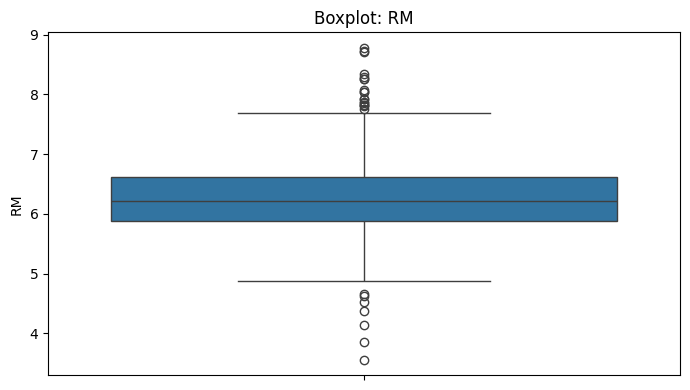

In [14]:
BOXPLOT_COL = "RM"

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_ml, y=BOXPLOT_COL, color="C0")
plt.title(f"Boxplot: {BOXPLOT_COL}")
plt.ylabel(BOXPLOT_COL)
plt.tight_layout()
plt.show()

## Выводы

В работе выполнена **прикладная** обработка пропусков: для **`CHAS`** использованы **режимные категории (мода)**, для **`LSTAT`** — **медиана** остальных значений столбца. Дальнейшие пропуски устранены **удалением строк**, что даёт множество `df_ml` без пропусков и пригодное для базового обучения регрессии по **`MEDV`**. Построен **boxplot** по **`RM`** для диагностики распределений и возможных выбросов перед моделированием.